# Chord Learning Screen Research

Started: 2026-05-15

## Feature Hypothesis

### Idea

Add a chord learning screen that helps Vibe-to-MIDI users understand the chord used in the current Dub Techno suggestion and manually recreate it in a DAW piano roll.

### Target user

- Android-first electronic music beginner or intermediate producer
- Knows the vibe they want, but does not know which notes, chord quality, inversion, rhythm, or voicing to enter in a DAW
- Wants practical DAW-ready guidance more than a full music-theory course

### Problem

Existing chord tools often generate progressions or teach broad theory, but Vibe-to-MIDI needs a narrow workflow: explain the currently recommended chord as notes, MIDI numbers, voicing, timing, and sound context so the user can hear it and type it into a DAW.

### MVP scope

- Show root, quality, intervals, note names, MIDI note numbers, and octave
- Show a compact piano-roll style chord diagram for 1 bar / 16 steps
- Explain Dub Techno-relevant qualities first: minor, minor7, minor9, sus4, dominant7
- Link the screen to the current suggestion rather than building a standalone encyclopedia
- Include chord stab timing, length, velocity guidance, and filter/delay context when available

### Non-goals

- Full ear-training system
- Full chord progression generator
- Song-level harmonic analysis
- AI chord generation
- Real MIDI export in this feature slice

### Research questions

1. Do adjacent tools validate demand for chord learning, chord generation, and DAW-ready MIDI output?
2. Which parts of competitor workflows are worth copying, narrowing, or avoiding?
3. Should the MVP be a standalone theory screen or contextual learning inside the current suggestion flow?
4. What risks matter for implementation in the existing Expo/React Native app?


## Source Notes

- https://www.hooktheory.com/support/hookpad — Hookpad emphasizes chord-by-chord composition, piano-roll-like editing, suggestions, bass lines, and export paths.
- https://www.hooktheory.com/faq — Hookpad positions itself as a browser composition tool with a separate chord staff and MIDI export in the full version.
- https://www.hooktheory.com/hookpad/pricing — Hookpad pricing page lists Chord Search and MIDI export, validating DAW-oriented chord workflow demand.
- https://scalermusic.com/products/scaler-3-education/ — Scaler 3 focuses on key/scale detection, chord suggestions, chord sets, and education-oriented licensing.
- https://scalermusic.com/wp-content/uploads/2025/06/Scaler-3-User-Guide-Print-Version.pdf — Scaler documentation shows a broad chord/progression/MIDI workflow, useful as a complexity caution.
- https://www.ableton.com/en/live-manual/11/live-midi-effect-reference/ — Ableton's Chord MIDI effect confirms a DAW-native mental model: one note plus interval offsets creates a chord.
- https://sonid.app/ — Sonid validates practical music-theory learning for notes, intervals, scales, chords, modes, and ear training.
- https://www.chordgen.org/ — ChordGen validates mood/prompt-to-chord generation with visual piano and MIDI export.
- https://www.chordoo.com/ — Chordoo validates genre-based chord progression generation and free MIDI export for DAWs.
- https://www.ototheory.com/ — OtoTheory combines chord progression building, theory insight, instrument views, and multi-track MIDI export.
- https://www.chordbot.com/ — Chordbot validates simple chord progression playback and MIDI export as a long-running mobile-friendly workflow.
- https://support.chordify.net/hc/en-us/articles/360002273038-Chordify-Apps — Chordify validates Android/iOS chord learning and chord trainer demand, though it is song-learning oriented rather than producer-prompt oriented.
- https://www.reddit.com/r/Scaler3/comments/1mbvi92/why_is_scaler_3_have_such_a_weird_interface/ — User discussion suggests complex chord tools can feel overloaded; simplicity is a product advantage.


## Data / Analysis


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

feature_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('research/features/2026-05-15_chord-learning-screen')
figures_dir = feature_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

competitors = pd.DataFrame([
    {
        'name': 'Hookpad',
        'category': 'composition / chord helper',
        'platform': 'web',
        'android_support': False,
        'daw_ready_output': True,
        'vibe_mapping': 'partial',
        'learning_depth': 'medium',
        'complexity_risk': 'medium',
        'mvp_takeaway': 'Separate chord staff and MIDI export validate DAW-ready chord representation.',
    },
    {
        'name': 'Scaler 3',
        'category': 'plugin / chord progression system',
        'platform': 'desktop plugin / standalone',
        'android_support': False,
        'daw_ready_output': True,
        'vibe_mapping': 'partial',
        'learning_depth': 'high',
        'complexity_risk': 'high',
        'mvp_takeaway': 'Powerful reference, but avoid broad DAW/plugin complexity in a mobile MVP.',
    },
    {
        'name': 'Sonid',
        'category': 'music theory learning',
        'platform': 'mobile / web',
        'android_support': True,
        'daw_ready_output': False,
        'vibe_mapping': 'none',
        'learning_depth': 'high',
        'complexity_risk': 'medium',
        'mvp_takeaway': 'Validates chord-quality learning, but Vibe-to-MIDI should stay applied and DAW-oriented.',
    },
    {
        'name': 'ChordGen',
        'category': 'AI chord generator',
        'platform': 'web',
        'android_support': 'browser',
        'daw_ready_output': True,
        'vibe_mapping': 'strong',
        'learning_depth': 'low',
        'complexity_risk': 'low',
        'mvp_takeaway': 'Mood-to-chord plus visual piano is close to Vibe-to-MIDI, but explanation depth is the gap.',
    },
    {
        'name': 'Chordoo',
        'category': 'genre chord generator',
        'platform': 'web',
        'android_support': 'browser',
        'daw_ready_output': True,
        'vibe_mapping': 'genre',
        'learning_depth': 'low',
        'complexity_risk': 'low',
        'mvp_takeaway': 'Genre-based generation reinforces that output should be immediately DAW usable.',
    },
    {
        'name': 'OtoTheory',
        'category': 'chord builder / theory companion',
        'platform': 'iOS / web',
        'android_support': False,
        'daw_ready_output': True,
        'vibe_mapping': 'partial',
        'learning_depth': 'medium',
        'complexity_risk': 'medium',
        'mvp_takeaway': 'Combines quick reference with production export; Android gap may be useful.',
    },
    {
        'name': 'Chordbot',
        'category': 'mobile chord progression playback',
        'platform': 'mobile',
        'android_support': True,
        'daw_ready_output': True,
        'vibe_mapping': 'none',
        'learning_depth': 'low',
        'complexity_risk': 'low',
        'mvp_takeaway': 'Simple playback plus MIDI export is a durable pattern for mobile chord tools.',
    },
    {
        'name': 'Chordify',
        'category': 'song chord learning',
        'platform': 'mobile / web',
        'android_support': True,
        'daw_ready_output': True,
        'vibe_mapping': 'none',
        'learning_depth': 'medium',
        'complexity_risk': 'medium',
        'mvp_takeaway': 'Android chord education is proven, but Vibe-to-MIDI should focus on original production rather than songs.',
    },
])

competitors


,name,category,platform,android_support,daw_ready_output,vibe_mapping,learning_depth,complexity_risk,mvp_takeaway
0,Hookpad,composition / chord helper,web,False,True,partial,medium,medium,Separate chord staff and MIDI export validate ...
1,Scaler 3,plugin / chord progression system,desktop plugin / standalone,False,True,partial,high,high,"Powerful reference, but avoid broad DAW/plugin..."
2,Sonid,music theory learning,mobile / web,True,False,none,high,medium,"Validates chord-quality learning, but Vibe-to-..."
3,ChordGen,AI chord generator,web,browser,True,strong,low,low,Mood-to-chord plus visual piano is close to Vi...
4,Chordoo,genre chord generator,web,browser,True,genre,low,low,Genre-based generation reinforces that output ...
5,OtoTheory,chord builder / theory companion,iOS / web,False,True,partial,medium,medium,Combines quick reference with production expor...
6,Chordbot,mobile chord progression playback,mobile,True,True,none,low,low,Simple playback plus MIDI export is a durable ...
7,Chordify,song chord learning,mobile / web,True,True,none,medium,medium,"Android chord education is proven, but Vibe-to..."


PosixPath('/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-15_chord-learning-screen/figures/chord_tool_signals.png')

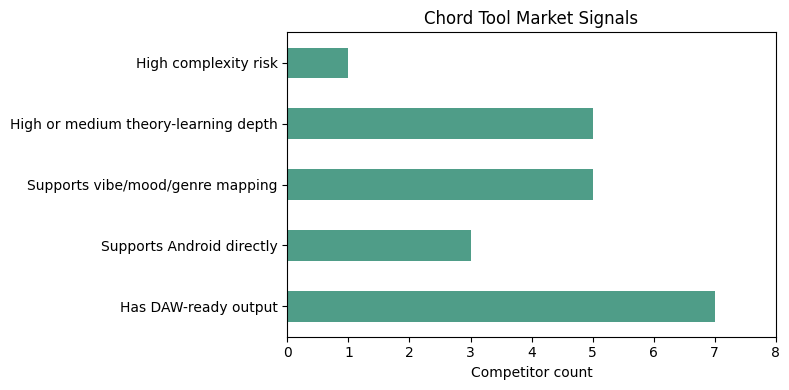

In [2]:
summary = pd.DataFrame({
    'signal': [
        'Has DAW-ready output',
        'Supports Android directly',
        'Supports vibe/mood/genre mapping',
        'High or medium theory-learning depth',
        'High complexity risk',
    ],
    'count': [
        int((competitors['daw_ready_output'] == True).sum()),
        int((competitors['android_support'] == True).sum()),
        int((competitors['vibe_mapping'] != 'none').sum()),
        int(competitors['learning_depth'].isin(['medium', 'high']).sum()),
        int((competitors['complexity_risk'] == 'high').sum()),
    ],
})

ax = summary.plot.barh(x='signal', y='count', legend=False, color='#4f9d88', figsize=(8, 4))
ax.set_title('Chord Tool Market Signals')
ax.set_xlabel('Competitor count')
ax.set_ylabel('')
ax.set_xlim(0, len(competitors))
plt.tight_layout()
chart_path = figures_dir / 'chord_tool_signals.png'
plt.savefig(chart_path, dpi=160)
chart_path


![Chord tool market signals](../figures/chord_tool_signals.png)


In [3]:
mvp_options = pd.DataFrame([
    {
        'option': 'Contextual chord learning panel',
        'build_cost': 2,
        'product_fit': 5,
        'daw_ready_value': 5,
        'risk': 2,
        'notes': 'Best first slice: explain current suggestion, chord notes, timing, and MIDI numbers.',
    },
    {
        'option': 'Standalone chord encyclopedia',
        'build_cost': 4,
        'product_fit': 3,
        'daw_ready_value': 2,
        'risk': 3,
        'notes': 'Useful but drifts toward generic theory apps and increases content maintenance.',
    },
    {
        'option': 'AI chord progression generator',
        'build_cost': 5,
        'product_fit': 4,
        'daw_ready_value': 4,
        'risk': 5,
        'notes': 'Competitive space is crowded; should wait until the explanation workflow is stronger.',
    },
    {
        'option': 'Real MIDI export',
        'build_cost': 4,
        'product_fit': 5,
        'daw_ready_value': 5,
        'risk': 4,
        'notes': 'High value, but better as the next phase after stable chord/rhythm representation.',
    },
])

mvp_options['score'] = mvp_options['product_fit'] + mvp_options['daw_ready_value'] - mvp_options['build_cost'] - mvp_options['risk']
mvp_options.sort_values('score', ascending=False)


,option,build_cost,product_fit,daw_ready_value,risk,notes,score
0,Contextual chord learning panel,2,5,5,2,"Best first slice: explain current suggestion, ...",6
3,Real MIDI export,4,5,5,4,"High value, but better as the next phase after...",2
1,Standalone chord encyclopedia,4,3,2,3,Useful but drifts toward generic theory apps a...,-2
2,AI chord progression generator,5,4,4,5,Competitive space is crowded; should wait unti...,-2


## Decision Summary

### Recommendation: Build, but narrow

Build a contextual chord learning screen/panel as the next feature slice. Do not build a full chord encyclopedia or AI progression generator yet.

### Evidence

- Adjacent products repeatedly combine chord help with DAW-ready output, especially MIDI export or MIDI-oriented editing.
- Android support exists for chord learning and mobile chord playback, but many producer-focused chord tools are web, desktop, plugin, or iOS-first. This leaves room for a focused Android-first workflow.
- Vibe/mood-to-chord tools exist, so the defensible difference is not merely generating chords. The stronger gap is explaining the current vibe suggestion clearly enough to manually recreate it in a DAW.
- User discussions around complex chord tools suggest a risk of overbuilding. The MVP should preserve speed and clarity.

### MVP recommendation

Add a `ChordLearningPanel` connected to the selected `MusicalSuggestion`:

1. Chord identity: root, quality, intervals, chord notes, MIDI note numbers.
2. Piano-roll view: 1 bar / 16 steps with chord stab positions and note lanes.
3. DAW input notes: octave, note length, velocity range, and chord voicing.
4. Dub Techno context: why minor7/minor9/sus4 stabs, lowpass filtering, and delay feedback create the intended feel.
5. Keep copy short and operational; avoid generic theory lessons.

### Risks

- Too much theory content could weaken the core vibe-to-MIDI workflow.
- A piano-roll diagram can become visually dense on small Android screens.
- If chord notes, preview audio, and MIDI instructions diverge, trust will drop quickly.
- Without MIDI export, users still need manual DAW entry; the screen must be precise enough to justify that step.

### Next step

Implement a narrow UI spike using existing `getChordNotes`, `daw-view`, and `MusicalSuggestion` data. Validate that every displayed note matches the preview engine and existing DAW panel.

### Notebook execution status

Executed successfully with `research/.venv/bin/jupyter nbconvert --to notebook --execute` on 2026-05-15. Generated `figures/chord_tool_signals.png`.


## Open Questions

- Should chord learning be a separate screen, a tab inside the current MIDI screen, or an expandable section below the current DAW steps panel?
- Which notation should be primary for Japanese users: English chord labels, solfege, or note names with MIDI numbers?
- Should the first UI show inversions, or keep all chords in root position until users ask for deeper control?
- What is the minimum piano-roll visualization that remains readable on small Android devices?
- Should the next implementation also add velocity values, or defer velocity until rhythm/groove learning work?
